<a href="https://colab.research.google.com/github/omonigho-egbo-15/-04NPY-Lab-Assignment/blob/main/PROGroup_Self.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Setup and Data Loading
Run this first to download the Student Dropout Prediction Dataset.
It started by loading the dataset and performing an initial check to understand its structure, identify data types, and spot any immediate issues like missing values.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Load the data (update path if the folder name differs)
df = pd.read_excel('/content/student_dropout_dataset_v3.csv.xlsx')
df.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


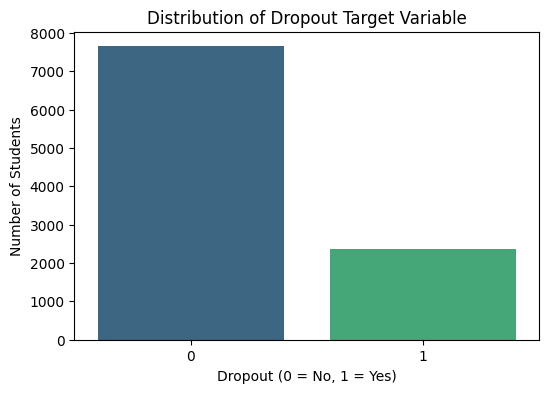

In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Dropout', hue='Dropout', data=df, palette='viridis', legend=False)
plt.title('Distribution of Dropout Target Variable')
plt.xlabel('Dropout (0 = No, 1 = Yes)')
plt.ylabel('Number of Students')
plt.show()

2. Data Cleaning and Preparation
This script implements a "clinical" engineering approach: handling missing values, removing duplicates, and engineering new features.

In [10]:
# 1. Handle Missing Values: Median for numbers, Mode for categories
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# 2. Remove Duplicates
df.drop_duplicates(inplace=True)

# 3. Feature Engineering
# Create a 'Risk_Score' (0-20 scale) based on Stress Index and Attendance
df['Risk_Score'] = (df['Stress_Index'] * 2) + (100 - df['Attendance_Rate']) / 10

# 4. Drop redundant columns (e.g., Student_ID)
if 'Student_ID' in df.columns:
    df.drop('Student_ID', axis=1, inplace=True)

print("Data cleaning completed successfully. Dataset dimensions:", df.shape)

Data cleaning completed successfully. Dataset dimensions: (10000, 19)


## Missing Values Check
Here i tried to check for any remaining missing values in the DataFrame after the cleaning process.

In [11]:
print('Missing values after cleaning:')
print(df.isnull().sum())

Missing values after cleaning:
Age                      0
Gender                   0
Family_Income            0
Internet_Access          0
Study_Hours_per_Day      0
Attendance_Rate          0
Assignment_Delay_Days    0
Travel_Time_Minutes      0
Part_Time_Job            0
Scholarship              0
Stress_Index             0
GPA                      0
Semester_GPA             0
CGPA                     0
Semester                 0
Department               0
Parental_Education       0
Dropout                  0
Risk_Score               0
dtype: int64


3. Analysis & Visualization
Here are the 4 analytical questions and their corresponding visualizations.

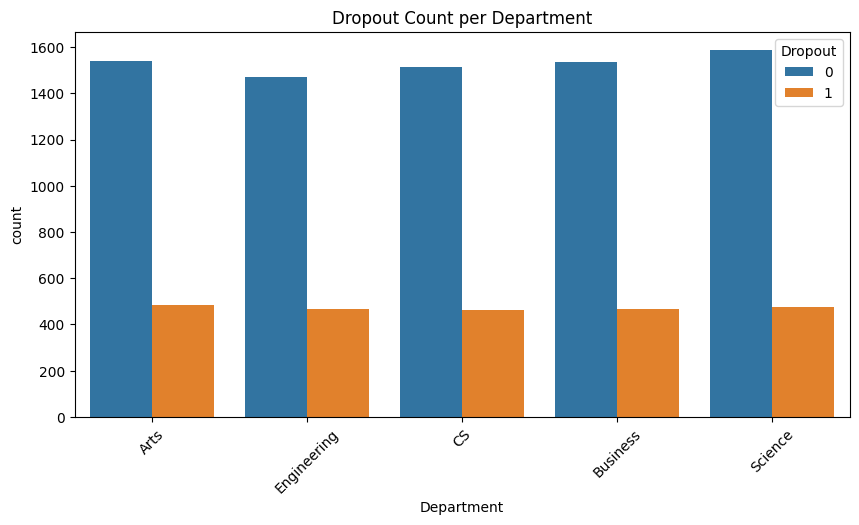

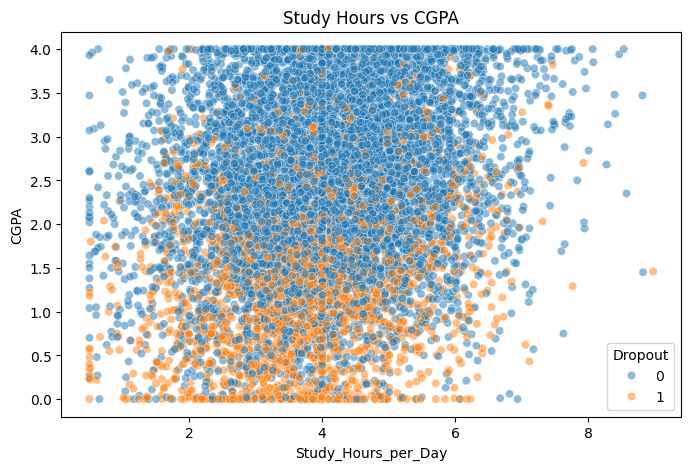

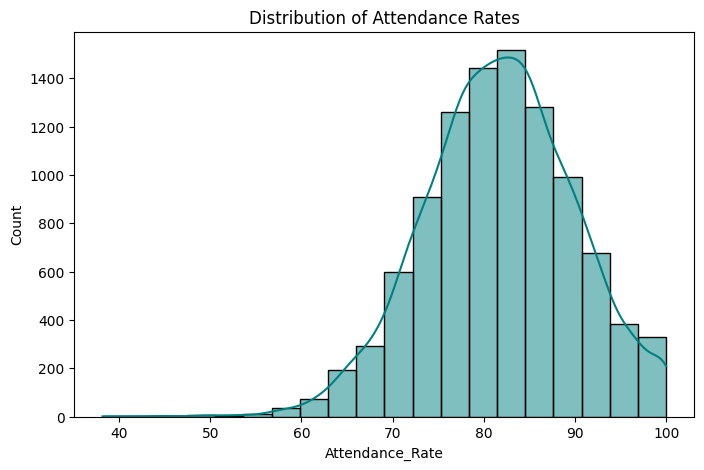

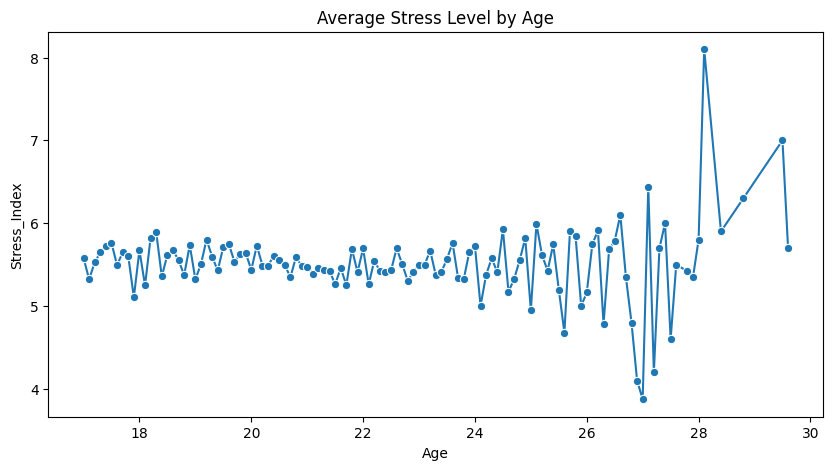

In [28]:
# Please ensure cells bvd59_3i1nzj and ImIO-bKJAZV1 are run first to define the 'df' DataFrame.

import matplotlib.pyplot as plt
import seaborn as sns

# Question 1: Which department has the highest dropout count?
plt.figure(figsize=(10, 5))
sns.countplot(x='Department', hue='Dropout', data=df)
plt.title('Dropout Count per Department')
plt.xticks(rotation=45)
plt.savefig('Dropout_Count_per_Department.png')
plt.show()
# Question 2: Is there a correlation between Study Hours and CGPA?
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Study_Hours_per_Day', y='CGPA', hue='Dropout', data=df, alpha=0.5)
plt.title('Study Hours vs CGPA')
plt.savefig('Study_Hours_vs_CGPA.png')
plt.show()

# Question 3: Distribution of Student Attendance Rates
plt.figure(figsize=(8, 5))
sns.histplot(df['Attendance_Rate'], bins=20, kde=True, color='teal')
plt.title('Distribution of Attendance Rates')
plt.savefig('Distribution_of_Attendance_Rates.png')
plt.show()

# Question 4: Trend of Stress Levels across Age groups
plt.figure(figsize=(10, 5))
avg_stress = df.groupby('Age')['Stress_Index'].mean().reset_index()
sns.lineplot(x='Age', y='Stress_Index', data=avg_stress, marker='o')
plt.title('Average Stress Level by Age')
plt.savefig('Average_Stress_Level_by_Age.png')
plt.show()

### Correlation Heatmap
Here, I visualize the correlation matrix to understand the relationships between numerical variables in the dataset.

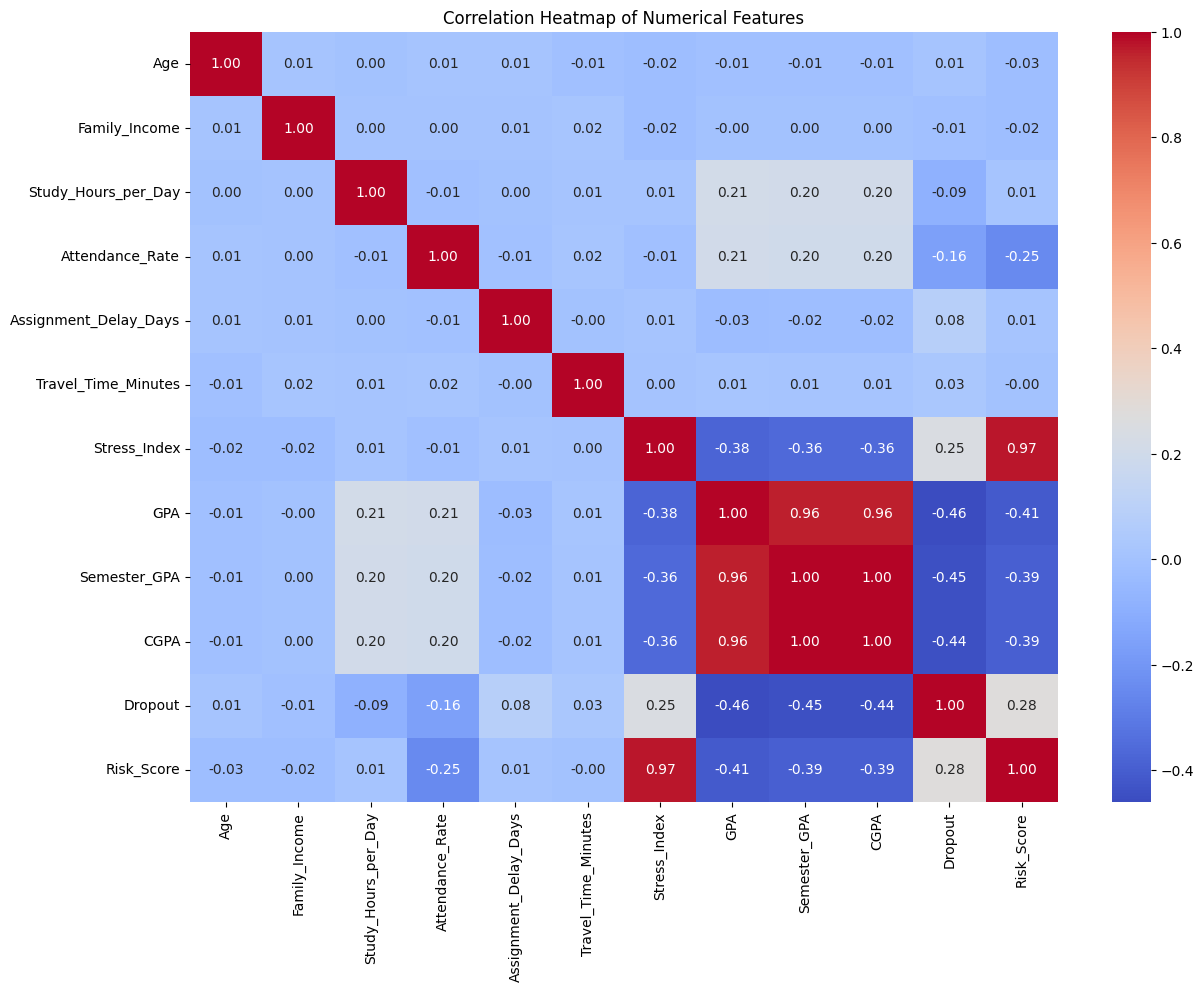

In [13]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.savefig('Correlation_Heatmap_of_Numerical_Features.png')
plt.show()

### Top 3 Factors Correlated with Dropout
Let's identify the numerical features that have the strongest correlation (positive or negative) with the 'Dropout' target variable.

In [14]:
# Calculate correlations with 'Dropout'
correlations = df.select_dtypes(include=np.number).corr()['Dropout'].abs().sort_values(ascending=False)

# Exclude 'Dropout' itself from the list
top_3_factors = correlations[1:4] # Take top 3 after 'Dropout' itself

print("Top 3 factors most strongly correlated with 'Dropout':")
print(top_3_factors)

Top 3 factors most strongly correlated with 'Dropout':
GPA             0.460352
Semester_GPA    0.445396
CGPA            0.444807
Name: Dropout, dtype: float64


### Visualizing the Strongest Correlated Factor ('GPA') with 'Dropout'
Generally, tied to visualize the relationship between 'GPA' and 'Dropout' using a boxplot.

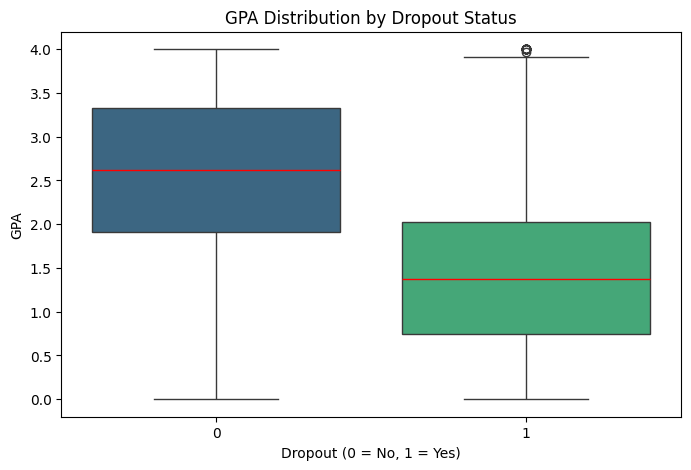

In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Dropout', y='GPA', hue='Dropout', data=df, palette='viridis', legend=False, medianprops={'color': 'red'})
plt.title('GPA Distribution by Dropout Status')
plt.xlabel('Dropout (0 = No, 1 = Yes)')
plt.ylabel('GPA')
plt.savefig('GPA_Distribution_by_Dropout_Status.png')
plt.show()

### Average Dropout Rate by Department
I tried visualize the average dropout rate across different departments to identify potential areas of concern or success.

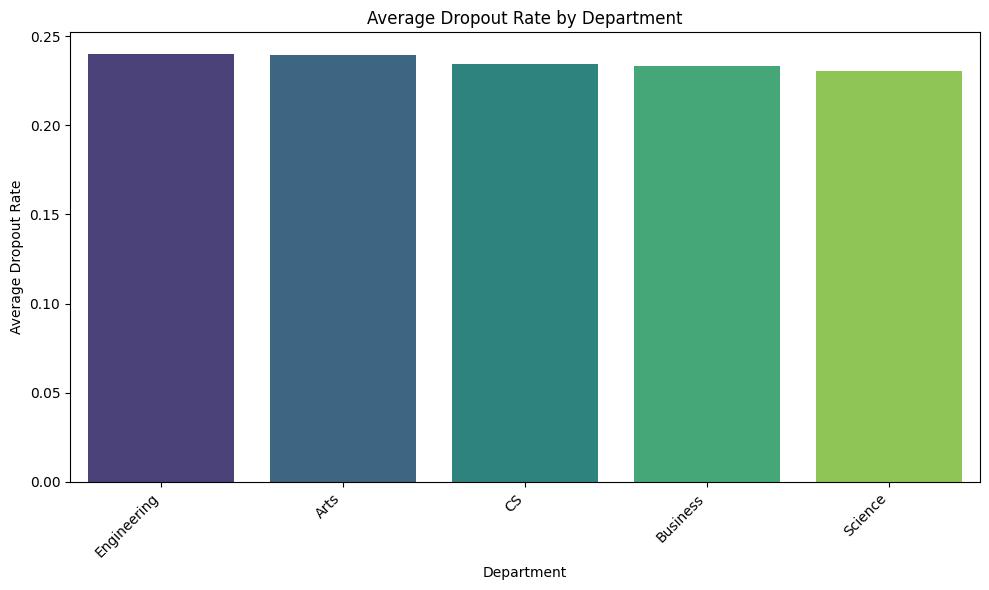

In [16]:
plt.figure(figsize=(10, 6))
avg_dropout_by_department = df.groupby('Department')['Dropout'].mean().sort_values(ascending=False).reset_index()
sns.barplot(x='Department', y='Dropout', hue='Department', data=avg_dropout_by_department, palette='viridis', legend=False)
plt.title('Average Dropout Rate by Department')
plt.xlabel('Department')
plt.ylabel('Average Dropout Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('Average_Dropout_Rate_by_Department.png')
plt.show()

### Visualizing 'Semester_GPA' with 'Dropout' Status
Here, I actually visualize the relationship between 'Semester_GPA' and 'Dropout' using a boxplot, as it was identified as one of the top correlated factors.

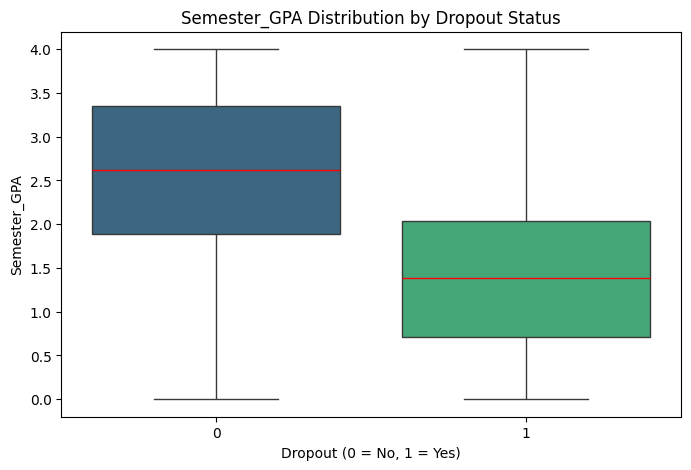

In [17]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Dropout', y='Semester_GPA', hue='Dropout', data=df, palette='viridis', legend=False, medianprops={'color': 'red'})
plt.title('Semester_GPA Distribution by Dropout Status')
plt.xlabel('Dropout (0 = No, 1 = Yes)')
plt.ylabel('Semester_GPA')
plt.savefig('Semester_GPA_Distribution_by_Dropout_Status.png')
plt.show()

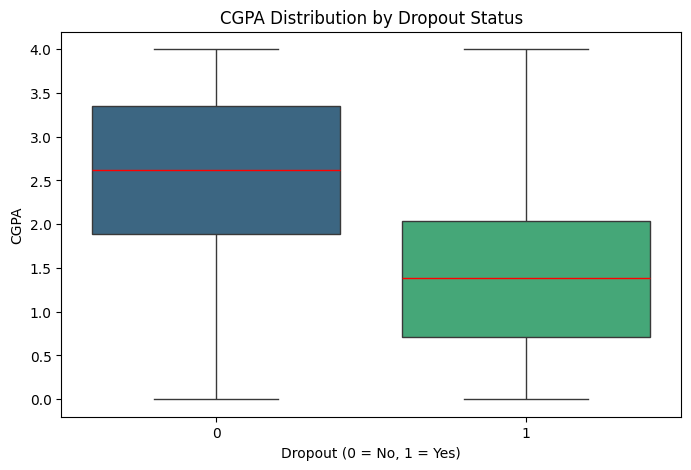

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Dropout', y='CGPA', hue='Dropout', data=df, palette='viridis', legend=False, medianprops={'color': 'red'})
plt.title('CGPA Distribution by Dropout Status')
plt.xlabel('Dropout (0 = No, 1 = Yes)')
plt.ylabel('CGPA')
plt.savefig('CGPA_Distribution_by_Dropout_Status_2.png')
plt.show()

### Re-engineering Academic Performance Indicators

Given that 'GPA', 'Semester_GPA', and 'CGPA' in the dataset are highly correlated with 'Dropout', I tried to combine these into a single 'Academic_Performance_Score'. Thus, I will then categorize this score to observe its impact on dropout rates.

Academic_Performance_Category
Medium Academic Performance    5002
High Academic Performance      2506
Low Academic Performance       2492
Name: count, dtype: int64


/tmp/ipykernel_4983/3010248645.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_dropout_by_academic_performance = df.groupby('Academic_Performance_Category')['Dropout'].mean().sort_values(ascending=False).reset_index()


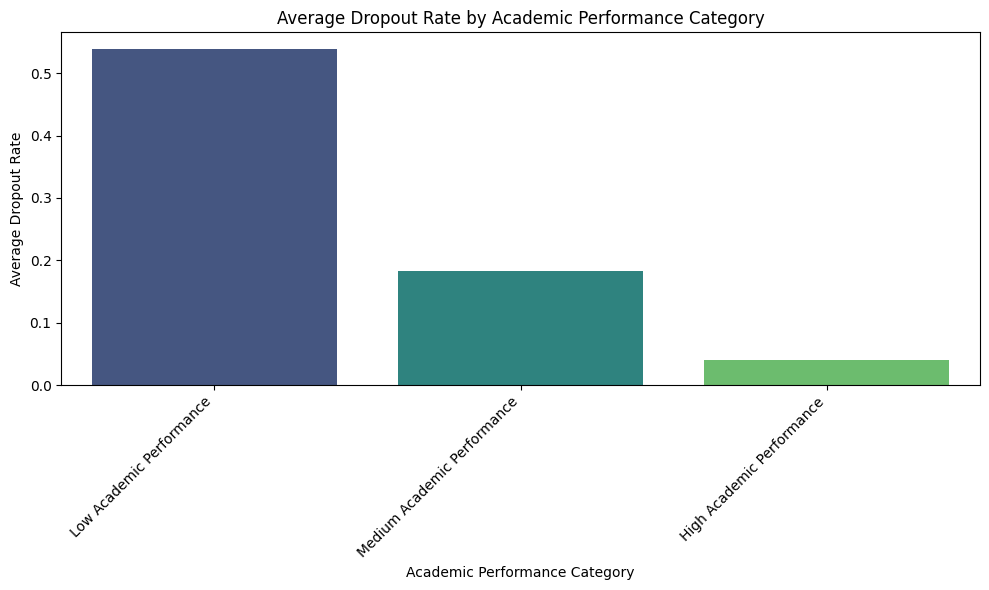

In [21]:
# Combine GPA, Semester_GPA, and CGPA into a single Academic_Performance_Score
df['Academic_Performance_Score'] = (df['GPA'] + df['Semester_GPA'] + df['CGPA']) / 3

# Define bins for Academic Performance Categories based on its distribution
min_score = df['Academic_Performance_Score'].min()
q1_score = df['Academic_Performance_Score'].quantile(0.25)
median_score = df['Academic_Performance_Score'].median()
q3_score = df['Academic_Performance_Score'].quantile(0.75)
max_score = df['Academic_Performance_Score'].max()

bins = [min_score, q1_score, q3_score, max_score + 1] # Using Q1, Q3 for Low/Medium/High
labels = ['Low Academic Performance', 'Medium Academic Performance', 'High Academic Performance']

df['Academic_Performance_Category'] = pd.cut(df['Academic_Performance_Score'], bins=bins, labels=labels, right=False)

# Display the count of each new category
print(df['Academic_Performance_Category'].value_counts())

# Visualize dropout rate by the new academic performance category
plt.figure(figsize=(10, 6))
avg_dropout_by_academic_performance = df.groupby('Academic_Performance_Category')['Dropout'].mean().sort_values(ascending=False).reset_index()
sns.barplot(x='Academic_Performance_Category', y='Dropout', hue='Academic_Performance_Category', data=avg_dropout_by_academic_performance, palette='viridis', legend=False)
plt.title('Average Dropout Rate by Academic Performance Category')
plt.xlabel('Academic Performance Category')
plt.ylabel('Average Dropout Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('Average_Dropout_Rate_by_Academic_Performance_Category.png')
plt.show()

In [22]:
print("DataFrame with 'Academic_Performance_Score':")
display(df[['GPA', 'Semester_GPA', 'CGPA', 'Academic_Performance_Score']].head())

DataFrame with 'Academic_Performance_Score':


,GPA,Semester_GPA,CGPA,Academic_Performance_Score
0,0.96,0.90,0.90,0.920000
1,1.28,1.20,1.19,1.223333
2,1.68,1.32,1.32,1.440000
3,1.78,1.77,1.77,1.773333
4,1.48,0.91,0.87,1.086667


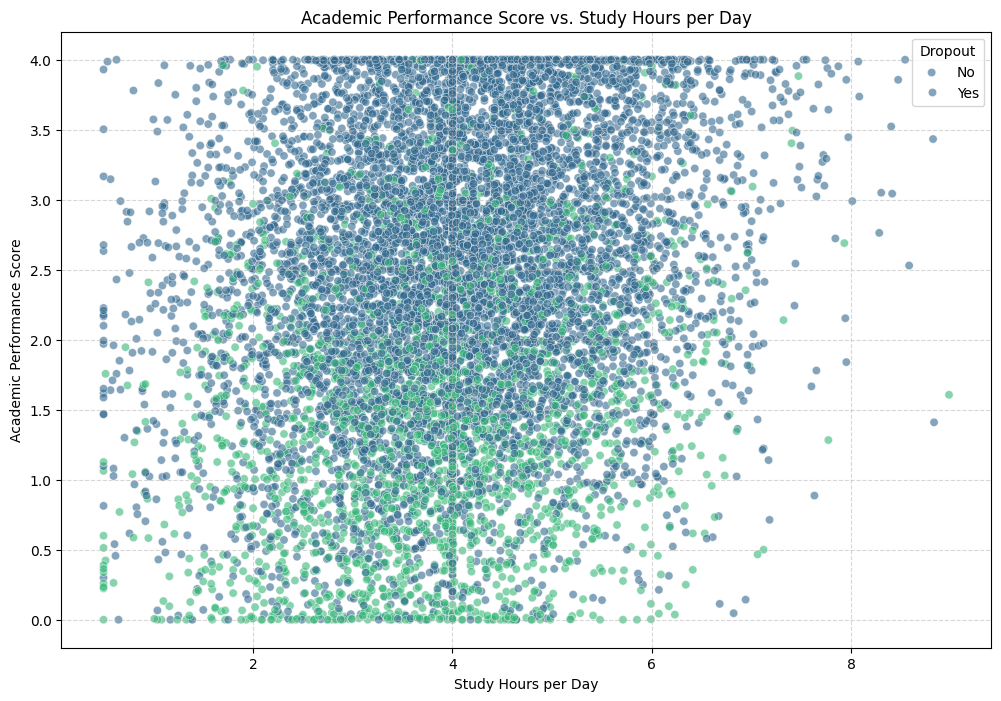

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the scatter plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df,
    x='Study_Hours_per_Day',
    y='Academic_Performance_Score',
    hue='Dropout',
    palette='viridis',
    alpha=0.6
)

# Adding titles and labels
plt.title('Academic Performance Score vs. Study Hours per Day')
plt.xlabel('Study Hours per Day')
plt.ylabel('Academic Performance Score')
plt.legend(title='Dropout', labels=['No', 'Yes'])
plt.grid(True, linestyle='--', alpha=0.5)

# Save and show the plot
plt.savefig('Academic_Performance_vs_Study_Hours.png')
plt.show()

### Comparing Dropout Status by Gender
Here I tried to examine how dropout rates differ between genders using a countplot.

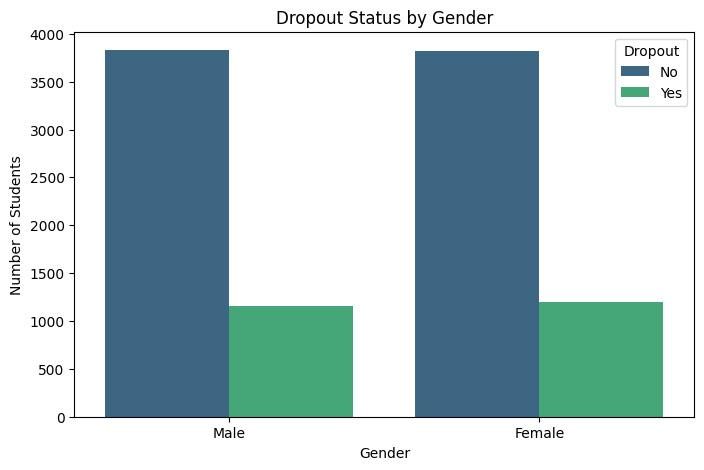

In [24]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Gender', hue='Dropout', data=df, palette='viridis')
plt.title('Dropout Status by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Students')
plt.legend(title='Dropout', labels=['No', 'Yes'])
plt.savefig('Dropout_Status_by_Gender_Countplot.png')
plt.show()

### Visualizing Dropout vs. Gender with a Pie Chart
To further understand the relationship between gender and dropout, I tried to visualize the proportions of each gender-dropout combination in a pie chart.

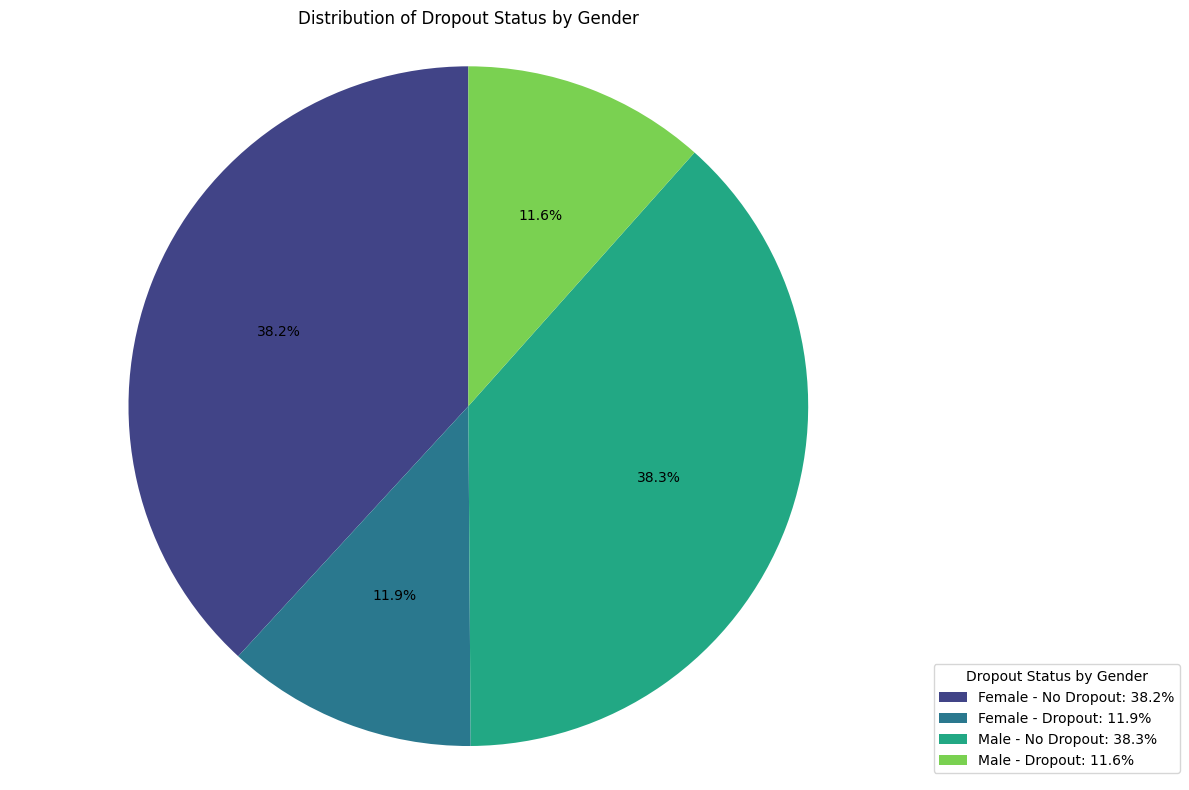

In [25]:
# Calculate the counts for each combination of Gender and Dropout
df_gender_dropout = df.groupby(['Gender', 'Dropout']).size().reset_index(name='Count')

# Calculate the percentage for each segment
df_gender_dropout['Percentage'] = (df_gender_dropout['Count'] / df_gender_dropout['Count'].sum()) * 100

# Create labels for the pie chart (for the legend)
df_gender_dropout['Label'] = df_gender_dropout.apply(lambda row: f"{row['Gender']} - {'Dropout' if row['Dropout']==1 else 'No Dropout'}: {row['Percentage']:.1f}%", axis=1)

# Create the pie chart
plt.figure(figsize=(12, 8)) # Increased figure size to accommodate legend
wedges, texts, autotexts = plt.pie(df_gender_dropout['Percentage'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis', len(df_gender_dropout)))
plt.title('Distribution of Dropout Status by Gender')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

# Add a legend
plt.legend(wedges, df_gender_dropout['Label'], title="Dropout Status by Gender", loc="lower left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.tight_layout() # Adjust layout to prevent legend from overlapping
plt.savefig('Distribution_of_Dropout_Status_by_Gender_Pie_Chart.png')
plt.show()

### Comparing Dropout Status with Family Income
To investigate how 'Family_Income' relates to 'Dropout' status using a boxplot.

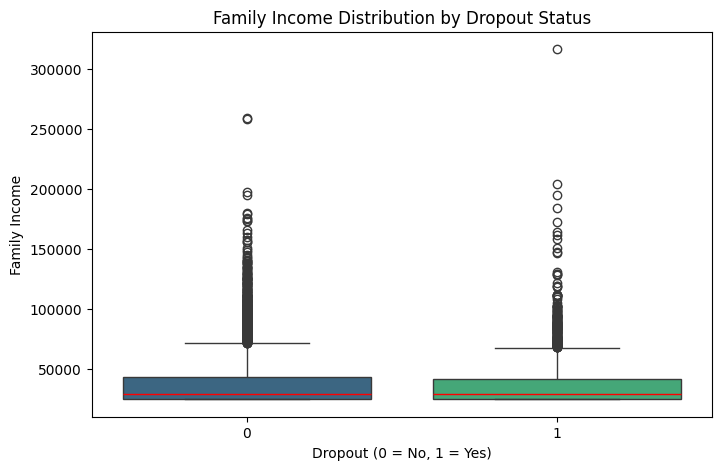

In [26]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Dropout', y='Family_Income', hue='Dropout', data=df, palette='viridis', legend=False, medianprops={'color': 'red'})
plt.title('Family Income Distribution by Dropout Status')
plt.xlabel('Dropout (0 = No, 1 = Yes)')
plt.ylabel('Family Income')
plt.savefig('Family_Income_Distribution_by_Dropout_Status.png')
plt.show()

### Categorizing Family Income for Better Analysis
To make 'Family_Income' more interpretable and to analyze its relationship with 'Dropout' status more clearly, I categorized it into different income levels. I first, examine the distribution of 'Family_Income'.

Family_Income_Category
Low Income       4750
Medium Income    2750
High Income      2500
Name: count, dtype: int64


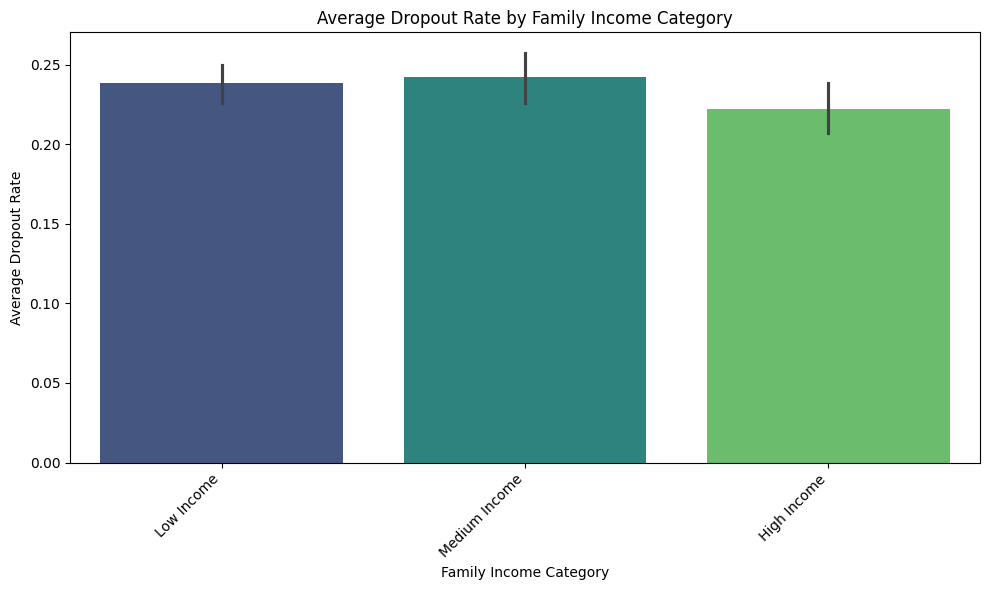

In [27]:
# Define bins for income categories based on descriptive statistics
# Using quartiles and max value as a guide for reasonable thresholds
min_income = df['Family_Income'].min()
q1_income = df['Family_Income'].quantile(0.25) # 25000
median_income = df['Family_Income'].median() # 29740.5
q3_income = df['Family_Income'].quantile(0.75) # 43361.75
max_income = df['Family_Income'].max() # 316601.0

# Adjusting bins to ensure all categories are populated
# Using min, median, and Q3 to create more balanced categories
bins = [min_income, median_income, q3_income, max_income + 1]
labels = ['Low Income', 'Medium Income', 'High Income']

df['Family_Income_Category'] = pd.cut(df['Family_Income'], bins=bins, labels=labels, right=False)

# Display the count of each new category
print(df['Family_Income_Category'].value_counts())

# Visualize dropout rate by new income category
plt.figure(figsize=(10, 6))
sns.barplot(x='Family_Income_Category', y='Dropout', hue='Family_Income_Category', data=df, palette='viridis', legend=False)
plt.title('Average Dropout Rate by Family Income Category')
plt.xlabel('Family Income Category')
plt.ylabel('Average Dropout Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('Average_Dropout_Rate_by_Family_Income_Category.png')
plt.show()